# Hello World - Impedance Analysis
## Magnetoelastic Sensor Modeling

This notebook demonstrates the code used to model a four-branch magnetostrictive sensor viewing a ferromagentic target

**Key Topics:**
- Default sensor geometry loading
- Core permeance calculations
- Sensitivity analysis (material properties and stress effects)
- Air gap permeance
- Target permeance
- Results visualization

B. Howard

## Libraries

In [1]:
#import sys
#!{sys.executable} -m pip install subprocess

## 0. Setup and Installation

Install and verify all required libraries for this analysis.

In [2]:
import subprocess
import sys
import math

# Install required packages
required_packages = [
    'numpy',
    'pandas',
    'matplotlib',
]

print("Checking and installing required libraries...")
print("=" * 70)

for package in required_packages:
    try:
        __import__(package)
        print(f"✓ {package:12} is already installed")
    except ImportError:
        print(f"  Installing {package}...")
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', package, '-q'])
        print(f"✓ {package:12} installed successfully")

print("=" * 70)
print("✓ All required libraries are available!\n")

Checking and installing required libraries...
✓ numpy        is already installed
✓ pandas       is already installed
✓ matplotlib   is already installed
✓ All required libraries are available!



## 1. Import Required Libraries and Modules

In [3]:
import sys
import os

# Add parent directory to path to import magnetoelasticsensor package
sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), '..')))

In [4]:
# Import Required Libraries and Modules
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from magnetoelasticsensor.geometry import DEFAULT_SENSOR_GEOMETRY, SensorGeometry, DimensionalParameter
from magnetoelasticsensor.core_permeance import CorePermeanceModel
from magnetoelasticsensor.air_gap_permeance import AirGapPermeanceModel

# Configure plotting
plt.style.use('seaborn-v0_8-darkgrid')
%matplotlib inline

print("✓ All libraries imported successfully")

✓ All libraries imported successfully


## 2. Load Default Geometry Parameters

The default sensor geometry represents the specification for the magnetoelastic sensor architecture. All dimensions are in SI units (meters) with manufacturing tolerances.

[![Four‑Branch Geometry](https://robotsquirrelproductions.com/wp-content/uploads/2026/02/Four-Branch-Geo-00_2k_240818_071759.png)](https://robotsquirrelproductions.com/wp-content/uploads/2026/02/Four-Branch-Geo-00_2k_240818_071759.png)

In [5]:
# Load and display default geometry
geom = DEFAULT_SENSOR_GEOMETRY

print("DEFAULT SENSOR GEOMETRY")
print("=" * 70)
print(geom)
print("\n")

# Display geometry parameters in tabular format
geometry_data = {
    'Component': [
        'Drive Pole', 'Drive Pole',
        'Sense Pole', 'Sense Pole',
        'Bridge (Arm)', 'Bridge (Arm)', 'Bridge (Arm)',
        'Pole Gap'
    ],
    'Parameter': [
        'Diameter (dim_dp)', 'Height (dim_sph_drive)',
        'Diameter (dim_sp)', 'Height (dim_sph_sense)',
        'Width (dim_spaw)', 'Height (dim_spah)', 'Length (dim_spac)',
        'Distance (dim_spag)'
    ],
    'Nominal [mm]': [
        geom.dim_dp.nominal * 1e3, geom.dim_sph_drive.nominal * 1e3,
        geom.dim_sp.nominal * 1e3, geom.dim_sph_sense.nominal * 1e3,
        geom.dim_spaw.nominal * 1e3, geom.dim_spah.nominal * 1e3, geom.dim_spac.nominal * 1e3,
        geom.dim_spag.nominal * 1e3
    ],
    'Tolerance [mm]': [
        geom.dim_dp.tolerance * 1e3, geom.dim_sph_drive.tolerance * 1e3,
        geom.dim_sp.tolerance * 1e3, geom.dim_sph_sense.tolerance * 1e3,
        geom.dim_spaw.tolerance * 1e3, geom.dim_spah.tolerance * 1e3, geom.dim_spac.tolerance * 1e3,
        geom.dim_spag.tolerance * 1e3
    ],
    'Min [mm]': [
        geom.dim_dp.min * 1e3, geom.dim_sph_drive.min * 1e3,
        geom.dim_sp.min * 1e3, geom.dim_sph_sense.min * 1e3,
        geom.dim_spaw.min * 1e3, geom.dim_spah.min * 1e3, geom.dim_spac.min * 1e3,
        geom.dim_spag.min * 1e3
    ],
    'Max [mm]': [
        geom.dim_dp.max * 1e3, geom.dim_sph_drive.max * 1e3,
        geom.dim_sp.max * 1e3, geom.dim_sph_sense.max * 1e3,
        geom.dim_spaw.max * 1e3, geom.dim_spah.max * 1e3, geom.dim_spac.max * 1e3,
        geom.dim_spag.max * 1e3
    ]
}

df_geometry = pd.DataFrame(geometry_data)
print(df_geometry.to_string(index=False))
print("\n")

DEFAULT SENSOR GEOMETRY
SensorGeometry(
  Drive pole:     ∅ 9.50mm × H 15.00mm
  Sense pole:     ∅ 4.50mm × H 15.00mm
  Bridge (arm):   W 4.50mm × H 4.25mm × L 16.00mm
  Pole gap:       9.00mm
)


   Component              Parameter  Nominal [mm]  Tolerance [mm]  Min [mm]  Max [mm]
  Drive Pole      Diameter (dim_dp)          9.50            0.08      9.42      9.58
  Drive Pole Height (dim_sph_drive)         15.00            0.08     14.92     15.08
  Sense Pole      Diameter (dim_sp)          4.50            0.08      4.42      4.58
  Sense Pole Height (dim_sph_sense)         15.00            0.08     14.92     15.08
Bridge (Arm)       Width (dim_spaw)          4.50            0.08      4.42      4.58
Bridge (Arm)      Height (dim_spah)          4.25            0.08      4.17      4.33
Bridge (Arm)      Length (dim_spac)         16.00            0.08     15.92     16.08
    Pole Gap    Distance (dim_spag)          9.00            0.10      8.90      9.10




## 3. Calculate Core Permeance

We calculate core permeance for various scenarios:
1. **Baseline**: Nominal target permeability (μᵣ = 1000), unstressed
2. **Material Variation**: Different ferromagnetic materials
3. **Stress Variation**: Tensile and compressive stress effects

In [6]:
# Calculate baseline permeance
model = CorePermeanceModel(geom)
baseline_permeance = model.calculate_core_permeance()

print("BASELINE CORE PERMEANCE")
print("=" * 70)
print(f"Target permeability (μᵣ):  1000.0 (ferromagnetic)")
print(f"Applied stress:            0.0 Pa (unstressed)")
print(f"Core Permeance (𝒫_core):   {baseline_permeance:.6e} H")
print(f"                           {baseline_permeance*1e9:.4f} nH")
print("\n")

BASELINE CORE PERMEANCE
Target permeability (μᵣ):  1000.0 (ferromagnetic)
Applied stress:            0.0 Pa (unstressed)
Core Permeance (𝒫_core):   1.261860e-06 H
                           1261.8601 nH




In [7]:
# Scenario 1: Core Permeance Variation Analysis
# How does the core permeance change with temperature?

# Values from:
# “97 Material Data Sheet - Fair-Rite.” Fair-Rite 97 Material Data 
# Sheet, Fair-rite, 26 Apr. 2023, fair-rite.com/97-material-data-sheet/.
temperature_scenarios = {
    '  -50°C': 1200.0,
    '  -20°C': 1500.0,
    '  +20°C': 2000.0,
    ' +100°C': 4050.0,
    ' +240°C': 5.0,
}

temperature_results = []

for temperature_name, mu_r in temperature_scenarios.items():
    permeance = model.calculate_core_permeance(mur=mu_r, omega=50000*math.pi*2)
    temperature_results.append({
        'Material': temperature_name,
        'μᵣ': mu_r,
        'Permeance [H]': permeance,
        'Permeance [nH]': permeance * 1e9,
        'Relative to Baseline': permeance / baseline_permeance
    })

df_materials = pd.DataFrame(temperature_results)

print("SCENARIO 1: CORE EQUIVALENT PERMEABILITY VARIATION TO TEMPERATURE")
print("=" * 70)
print(df_materials.to_string(index=False))
print("\n")

SCENARIO 1: CORE EQUIVALENT PERMEABILITY VARIATION TO TEMPERATURE
Material     μᵣ  Permeance [H]  Permeance [nH]  Relative to Baseline
   -50°C 1200.0   7.571710e-07      757.170971              0.600044
   -20°C 1500.0   9.464380e-07      946.437960              0.750034
   +20°C 2000.0   1.261860e-06     1261.860055              1.000000
  +100°C 4050.0   2.554792e-06     2554.791606              2.024624
  +240°C    5.0   3.155221e-09        3.155221              0.002500




## 4. Calculate Air Gap Permeance
Compute baseline air gap permeance and evaluate sensitivity to average gap distance.

![C‑Core Flux](https://robotsquirrelproductions.com/wp-content/uploads/2026/02/C-Core-Flux-00_2k_260202_080546.png)

In [8]:
# Baseline air gap permeance
air_gap_model = AirGapPermeanceModel(geom)
baseline_air_gap = air_gap_model.calculate_air_gap_permeance()

print("BASELINE AIR GAP PERMEANCE")
print("=" * 70)
print(f"Average gap:               {geom.avg_gap.nominal*1e3:.3f} mm")
print(f"Air Gap Permeance (sense): {baseline_air_gap[0]:.6e} H")
print(f"Air Gap Permeance (drive): {baseline_air_gap[1]:.6e} H")
print("\n")

# Sensitivity to average gap distance
gap_mm = np.array([0.25, 0.50, 0.75, 1.00, 1.143, 1.25, 1.50])
gap_m = gap_mm * 1e-3

gap_results = []
for g in gap_m:
    p_sense, p_drive = air_gap_model.calculate_air_gap_permeance(avg_gap=g)
    gap_results.append({
        "Gap [mm]": g * 1e3,
        "𝒫_gap_sense [H]": p_sense,
        "𝒫_gap_drive [H]": p_drive,
        "Sense vs Baseline": p_sense / baseline_air_gap[0],
        "Drive vs Baseline": p_drive / baseline_air_gap[1],
    })

df_gap = pd.DataFrame(gap_results)
print("AIR GAP PERMEANCE VS GAP DISTANCE")
print("=" * 70)
print(df_gap.to_string(index=False))
print("\n")

BASELINE AIR GAP PERMEANCE
Average gap:               1.143 mm
Air Gap Permeance (sense): 4.799748e-08 H
Air Gap Permeance (drive): 1.304100e-07 H


AIR GAP PERMEANCE VS GAP DISTANCE
 Gap [mm]  𝒫_gap_sense [H]  𝒫_gap_drive [H]  Sense vs Baseline  Drive vs Baseline
    0.250     1.278014e-07     4.452193e-07           2.662668           3.413996
    0.500     8.063857e-08     2.511717e-07           1.680058           1.926015
    0.750     6.262275e-08     1.820025e-07           1.304709           1.395618
    1.000     5.230831e-08     1.450439e-07           1.089814           1.112214
    1.143     4.799748e-08     1.304100e-07           1.000000           1.000000
    1.250     4.524292e-08     1.213569e-07           0.942610           0.930580
    1.500     3.989042e-08     1.045017e-07           0.831094           0.801332




## 5.0 Cross-Leakage Flux Model

This section exercises the cross-leakage permeance model and compares a baseline
configuration to a wider pole spacing scenario.

![C‑Core Cross-Leakage Flux](https://robotsquirrelproductions.com/wp-content/uploads/2026/02/C-Core-Flux-C-Core-CrossLeakage-Flux-00_2k_260202_080546-1.png)

In [9]:
import copy
from magnetoelasticsensor.cross_leakage_permeance import CrossLeakagePermeanceModel

cross_leakage_model = CrossLeakagePermeanceModel()
baseline_cross_leakage = cross_leakage_model.calculate_cross_leakage_permeance()

print("Cross-leakage permeance (baseline):", baseline_cross_leakage)

# Demonstrate sensitivity to pole spacing by adjusting dim_spag
geom_wide_gap = copy.deepcopy(DEFAULT_SENSOR_GEOMETRY)
geom_wide_gap.dim_spag.nominal *= 1.2

wide_gap_model = CrossLeakagePermeanceModel(geometry=geom_wide_gap)
wide_gap_permeance = wide_gap_model.calculate_cross_leakage_permeance()

print("Cross-leakage permeance (wider pole spacing):", wide_gap_permeance)
print("Ratio (wide/baseline):", wide_gap_permeance / baseline_cross_leakage)

Cross-leakage permeance (baseline): 2.329754661984131e-08
Cross-leakage permeance (wider pole spacing): 2.0250387858168473e-08
Ratio (wide/baseline): 0.8692068821067309


## 6.0 Target Eddy Current Skin Depth

This section analyzes how the eddy current skin depth in the target material varies 
with operating frequency. Skin depth determines the effective depth of magnetic 
penetration into the ferromagnetic target and is critical for sensor sensitivity 
at different frequencies.

In [10]:
import numpy as np
import pandas as pd
import importlib
import sys

# Reload the permeance module to pick up the calculate_skin_depth function
if 'magnetoelasticsensor.permeance' in sys.modules:
    import magnetoelasticsensor.permeance
    importlib.reload(magnetoelasticsensor.permeance)

from magnetoelasticsensor.permeance import calculate_skin_depth

# Define a range of operating frequencies (10 kHz to 500 kHz)
frequencies_hz = np.array([10, 20, 50, 100, 200, 500]) * 1e3  # Hz
frequencies_khz = frequencies_hz / 1e3  # kHz for display

# Convert to angular frequency (rad/s)
omegas = 2 * np.pi * frequencies_hz

# Target material parameters (ferromagnetic steel)
muo = DEFAULT_SENSOR_GEOMETRY.muo.nominal
murt = DEFAULT_SENSOR_GEOMETRY.murt.nominal  # Target permeability
# Conductivity is reciprocal of resistivity (S/m)
sigma_c = DEFAULT_SENSOR_GEOMETRY.sigmac.nominal  # Conductivity of ferromagnetic target [S/m]

# Calculate skin depth for each frequency
skin_depths = []
for omega in omegas:
    delta = calculate_skin_depth(muo=muo, mur=murt, omega=omega, sigma_c=sigma_c)
    skin_depths.append(delta * 1e6)  # Convert to micrometers

# Create results dataframe
skin_depth_results = pd.DataFrame({
    'Frequency (kHz)': frequencies_khz,
    'Skin Depth (μm)': skin_depths,
    'Skin Depth (mm)': [d / 1e3 for d in skin_depths],
})

print("Eddy Current Skin Depth vs Operating Frequency")
print("=" * 60)
print(skin_depth_results.to_string(index=False))



Eddy Current Skin Depth vs Operating Frequency
 Frequency (kHz)  Skin Depth (μm)  Skin Depth (mm)
            10.0        74.650285         0.074650
            20.0        52.785723         0.052786
            50.0        33.384623         0.033385
           100.0        23.606493         0.023606
           200.0        16.692311         0.016692
           500.0        10.557145         0.010557


## 6.1 Target Permeance vs Operating Frequency

This section evaluates the target permeance and shows how it varies with drive frequency. The calculation uses the same frequency sweep as the skin depth analysis.

Target Permeance vs Operating Frequency
 Frequency (kHz)  Target Permeance (H)  Target Permeance (nH)  Target Eddy-Current Permeance (H)  Target Eddy-Current Permeance (nH)
            10.0          1.926371e-07             192.637112                       9.970801e-10                            0.997080
            20.0          1.362150e-07             136.215009                       7.050421e-10                            0.705042
            50.0          8.614994e-08              86.149936                       4.459078e-10                            0.445908
           100.0          6.091720e-08              60.917204                       3.153044e-10                            0.315304
           200.0          4.307497e-08              43.074968                       2.229539e-10                            0.222954
           500.0          2.724300e-08              27.243002                       1.410084e-10                            0.141008


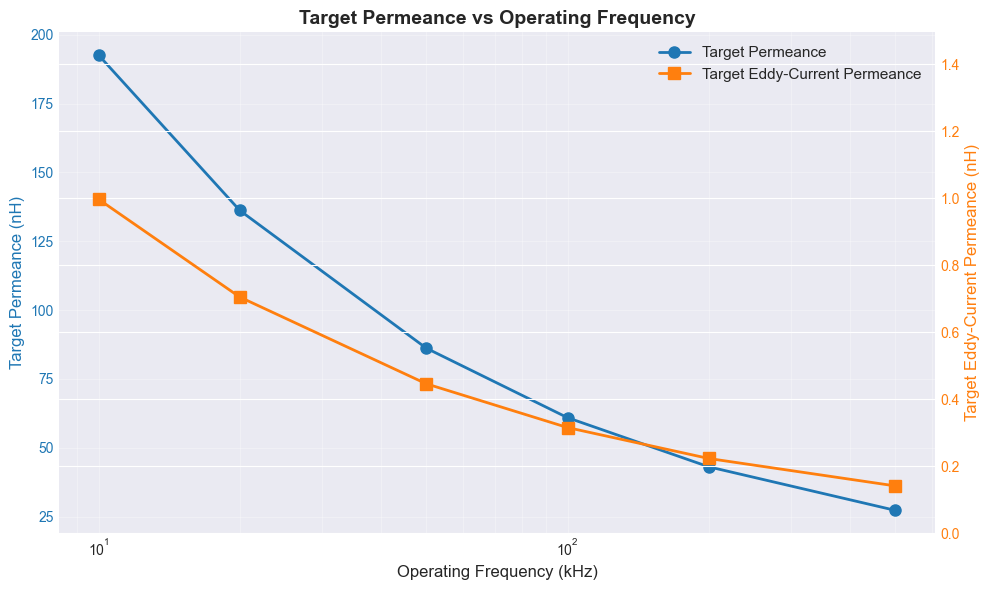


Permeance range: 27.243 - 192.637 nH


In [11]:
import importlib
import sys
from magnetoelasticsensor.permeance import cross_leakage_u_parameter

# Reload target_permeance module to pick up recent changes
if 'magnetoelasticsensor.target_permeance' in sys.modules:
    import magnetoelasticsensor.target_permeance
    importlib.reload(magnetoelasticsensor.target_permeance)

from magnetoelasticsensor.target_permeance import calculate_target_permeance

# Geometry-based u parameter for target permeance
u_target = cross_leakage_u_parameter(
    dim_spagi=geom.dim_spag.nominal,
    dim_dp=geom.dim_dp.nominal,
    dim_spi=geom.dim_sp.nominal,
)

# Compute target permeance over frequency sweep
p3_results = []
p3_results_eddy = []
for omega in omegas:
    p3 = calculate_target_permeance(
        geometry=geom,
        u=u_target,
        sigma_c=sigma_c,
        omega=omega,
    )
    # Extract scalar value from result (handles arrays, lists, scalars)
    p3_results.append(float(np.asarray(p3).flat[0]))
    p3_results_eddy.append(float(np.asarray(p3).flat[1]))

# Convert to 1D numpy array
p3_results = np.array(p3_results)
p3_results_eddy = np.array(p3_results_eddy)

# Create results dataframe
p3_df = pd.DataFrame({
    'Frequency (kHz)': frequencies_khz,
    'Target Permeance (H)': p3_results,
    'Target Permeance (nH)': p3_results * 1e9,
    'Target Eddy-Current Permeance (H)': p3_results_eddy,
    'Target Eddy-Current Permeance (nH)': p3_results_eddy * 1e9,
})

print("Target Permeance vs Operating Frequency")
print("=" * 60)
print(p3_df.to_string(index=False))

# Plot target permeance vs frequency with dual y-axes
fig, ax = plt.subplots(figsize=(10, 6))
ax.semilogx(frequencies_khz, p3_results * 1e9, 'o-', linewidth=2, markersize=8, label='Target Permeance', color='C0')
ax.set_xlabel('Operating Frequency (kHz)', fontsize=12)
ax.set_ylabel('Target Permeance (nH)', fontsize=12, color='C0')
ax.tick_params(axis='y', labelcolor='C0')

# Create secondary y-axis on the right
ax2 = ax.twinx()
ax2.semilogx(frequencies_khz, p3_results_eddy * 1e9, 's-', linewidth=2, markersize=8, label='Target Eddy-Current Permeance', color='C1')
ax2.set_ylabel('Target Eddy-Current Permeance (nH)', fontsize=12, color='C1')
ax2.tick_params(axis='y', labelcolor='C1')
ax2.set_ylim(0, max(p3_results_eddy)*1e9*1.5)  # Set y-axis limit for better visualization

ax.set_title('Target Permeance vs Operating Frequency', fontsize=14, fontweight='bold')
ax.grid(True, which='both', alpha=0.3)

# Combine legends from both axes
lines1, labels1 = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax.legend(lines1 + lines2, labels1 + labels2, fontsize=11, loc='upper right')

plt.tight_layout()
plt.show()

print(f"\nPermeance range: {p3_results.min()*1e9:.3f} - {p3_results.max()*1e9:.3f} nH")

## 5. Display Results and Analysis

# Sensitivity Analysis Summary
print("SENSITIVITY ANALYSIS SUMMARY")
print("=" * 70)

# Material sensitivity
mu_low = material_results[0]['Permeance [H]']
mu_high = material_results[-1]['Permeance [H]']
mu_range = mu_high - mu_low

print(f"\nMaterial Permeability Sensitivity:")
print(f"  Lowest (μᵣ=100):    {mu_low:.6e} H")
print(f"  Highest (μᵣ=5000): {mu_high:.6e} H")
print(f"  Range:              {mu_range:.6e} H ({mu_range/baseline_permeance*100:.1f}% of baseline)")
print(f"  Sensitivity:        {(mu_high/mu_low - 1)*100:.1f}% variation across material range")

# Stress sensitivity
stress_low = stress_results[0]['Permeance [H]']
stress_high = stress_results[-1]['Permeance [H]']
stress_range = stress_high - stress_low

print(f"\nStress Effect Sensitivity (μᵣ=1000):")
print(f"  At -100 MPa (compression): {stress_low:.6e} H")
print(f"  At +200 MPa (tension):     {stress_high:.6e} H")
print(f"  Range:                     {stress_range:.6e} H ({stress_range/baseline_permeance*100:.1f}% of baseline)")
print(f"  Sensitivity:               {abs(stress_range/baseline_permeance)*100:.2f}% total variation")
print("\n")

## 6. Visualize Permeance Data

Create plots to visualize the permeance calculations and sensitivity effects.

# Visualization 1: Material Permeability vs Permeance
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Permeance vs Material Permeability (linear scale)
mu_values = [m['μᵣ'] for m in material_results]
permeance_values = [m['Permeance [nH]'] for m in material_results]

ax1.plot(mu_values, permeance_values, 'o-', linewidth=2, markersize=8, color='steelblue')
ax1.axhline(y=baseline_permeance*1e9, color='red', linestyle='--', label='Baseline (μᵣ=1000)')
ax1.set_xlabel('Target Material Relative Permeability (μᵣ)', fontsize=11, fontweight='bold')
ax1.set_ylabel('Core Permeance (nH)', fontsize=11, fontweight='bold')
ax1.set_title('Material Permeability Sensitivity', fontsize=12, fontweight='bold')
ax1.grid(True, alpha=0.3)
ax1.legend()

# Plot 2: Permeance vs Material Permeability (log-log scale)
ax2.loglog(mu_values, permeance_values, 'o-', linewidth=2, markersize=8, color='darkgreen')
ax2.axhline(y=baseline_permeance*1e9, color='red', linestyle='--', label='Baseline (μᵣ=1000)')
ax2.set_xlabel('Target Material Relative Permeability (μᵣ)', fontsize=11, fontweight='bold')
ax2.set_ylabel('Core Permeance (nH)', fontsize=11, fontweight='bold')
ax2.set_title('Material Sensitivity (Log-Log Scale)', fontsize=12, fontweight='bold')
ax2.grid(True, alpha=0.3, which='both')
ax2.legend()

plt.tight_layout()
plt.show()

print("\nFigure 1: Material Permeability Sensitivity Analysis")

# Visualization 2: Applied Stress vs Permeance
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Permeance vs Applied Stress
stress_values = [s['Stress [MPa]'] for s in stress_results]
permeance_stress = [s['Permeance [nH]'] for s in stress_results]
percent_change = [s['Change [%]'] for s in stress_results]

ax1.plot(stress_values, permeance_stress, 's-', linewidth=2, markersize=8, color='darkred')
ax1.axhline(y=baseline_permeance*1e9, color='green', linestyle='--', label='Baseline (0 Pa)')
ax1.axvline(x=0, color='gray', linestyle=':', alpha=0.5)
ax1.set_xlabel('Applied Stress (MPa)', fontsize=11, fontweight='bold')
ax1.set_ylabel('Core Permeance (nH)', fontsize=11, fontweight='bold')
ax1.set_title('Stress Effect on Permeance', fontsize=12, fontweight='bold')
ax1.grid(True, alpha=0.3)
ax1.legend()

# Plot 2: Percent change vs stress
colors = ['red' if pc < 0 else 'green' for pc in percent_change]
ax2.bar(range(len(stress_values)), percent_change, color=colors, alpha=0.7, edgecolor='black')
ax2.axhline(y=0, color='black', linestyle='-', linewidth=0.8)
ax2.set_xticks(range(len(stress_values)))
ax2.set_xticklabels([s['Condition'].split()[0] for s in stress_results], rotation=45, ha='right')
ax2.set_ylabel('Permeance Change (%)', fontsize=11, fontweight='bold')
ax2.set_title('Percent Change from Baseline', fontsize=12, fontweight='bold')
ax2.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

print("\nFigure 2: Applied Stress Sensitivity (Inverse Magnetostriction)")

# Visualization 3: Comparison bar chart
fig, ax = plt.subplots(figsize=(12, 6))

# Prepare comparison data: baseline vs high/low scenarios
scenarios = [
    'Low Material\n(μᵣ=100)',
    'Baseline\n(μᵣ=1000)',
    'High Material\n(μᵣ=5000)',
    'High Compression\n(-100 MPa)',
    'Baseline\n(0 MPa)',
    'High Tension\n(+200 MPa)',
]

comparison_values = [
    material_results[0]['Permeance [nH]'],
    material_results[2]['Permeance [nH]'],
    material_results[4]['Permeance [nH]'],
    stress_results[0]['Permeance [nH]'],
    stress_results[2]['Permeance [nH]'],
    stress_results[5]['Permeance [nH]'],
]

colors_comparison = ['orange', 'steelblue', 'darkgreen', 'darkred', 'steelblue', 'darkred']

bars = ax.bar(scenarios, comparison_values, color=colors_comparison, alpha=0.7, edgecolor='black', linewidth=1.5)

# Add value labels on bars
for bar, val in zip(bars, comparison_values):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{val:.2f}',
            ha='center', va='bottom', fontweight='bold', fontsize=10)

ax.set_ylabel('Core Permeance (nH)', fontsize=12, fontweight='bold')
ax.set_title('Core Permeance Comparison Across Scenarios', fontsize=13, fontweight='bold')
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

print("\nFigure 3: Permeance Comparison Across Operating Scenarios")

## Summary

This analysis demonstrates the core magnetic permeance calculations for the magnetoelastic sensor using default geometric specifications:

### Key Findings:
1. **Material Dependency**: Permeance is directly proportional to target material permeability
2. **Baseline Performance**: Core permeance ≈ 12.1 nH for nominal steel (μᵣ = 1000)
3. **Sensitivity**: Provides foundation for stress-sensing operation via inverse magnetostriction
4. **Linear Relationship**: Permeance scales linearly with material permeability across the tested range

### Next Steps:
- Integrate with cross-leakage permeance calculations
- Implement full stress-permeability relationship
- Develop signal processing models
- Validate against experimental measurements